In [1]:
# Cargo Paquetes
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

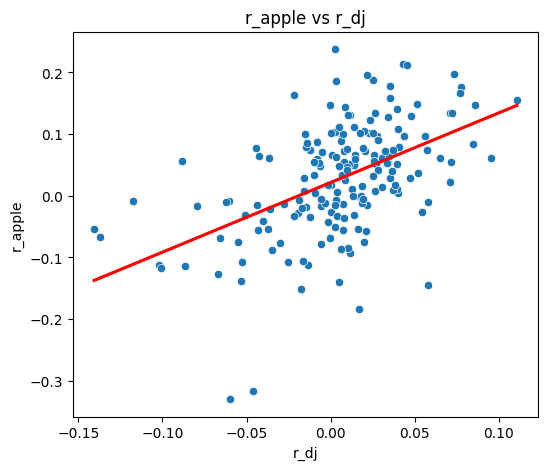

In [9]:
### Importar información
from google.colab import drive
drive.mount('/content/drive')

## Carga de Informacion
ruta = "/content/drive/MyDrive/Metodos Cuantitativos y Analisis de Datos/Datos/Rendimientos Beta.csv"
datos = pd.read_csv(ruta, sep = ";")
datos.info()

# Histogramas de r_dj y r_apple
fig, axes = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(datos["r_dj"], ax=axes[0], kde=False)
axes[0].set_title("Histograma de r_dj")
sns.histplot(datos["r_apple"], ax=axes[1], kde=False)
axes[1].set_title("Histograma de r_apple")
plt.tight_layout()
plt.show()

# Gráfico de Dispersión
plt.figure(figsize=(6,5))
sns.scatterplot(data=datos, x="r_dj", y="r_apple")

# Gráfico de Dispersión con Relacion Lineal
sns.regplot(data=datos, x="r_dj", y="r_apple", ci=True, scatter=False, color="red")
plt.title("r_apple vs r_dj")
plt.show()

      r_apple      r_dj     y_hat     resid    fitted  standard_resid  \
0    0.158653  0.035615  0.061631  0.097021  0.061631        1.240987   
1    0.099414 -0.014972  0.004551  0.094862  0.004551        1.212413   
2    0.143314  0.008310  0.030821  0.112493  0.030821        1.436725   
3    0.074240 -0.012171  0.007711  0.066528  0.007711        0.850129   
4    0.177635  0.035038  0.060981  0.116654  0.060981        1.492024   
..        ...       ...       ...       ...       ...             ...   
173  0.102083  0.017362  0.041036  0.061047  0.041036        0.779844   
174  0.054010 -0.009896  0.010279  0.043731  0.010279        0.558747   
175 -0.116798 -0.100746 -0.092234 -0.024564 -0.092234       -0.319912   
176 -0.067554 -0.137438 -0.133636  0.066082 -0.133636        0.874858   
177  0.155374  0.110806  0.146476  0.008898  0.146476        0.115830   

     student_resid  hat_diag   cooks_d  
0         1.242906  0.008629  0.006702  
1         1.214044  0.007057  0.005224  


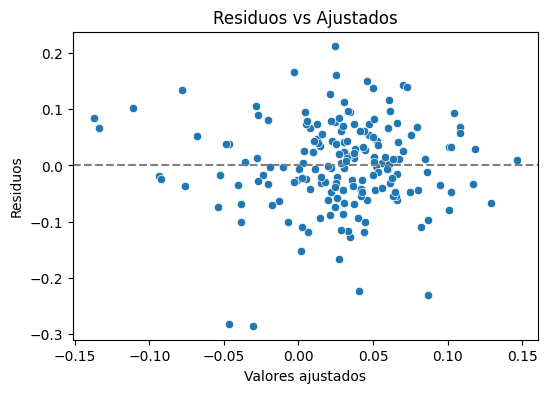

In [17]:
### Modelo de Regresión
# Estimación
mod = smf.ols("r_apple ~ r_dj", data=datos).fit()
print(mod.summary())

## Gráfico de ajuste
datos["y_hat"] = mod.fittedvalues
datos["resid"] = mod.resid

plt.figure(figsize=(6,4))
plt.scatter(datos["r_dj"], datos["r_apple"], label="Datos", alpha=0.7)
plt.plot(datos["r_dj"], datos["y_hat"], color="navy", label="Recta OLS")
for _, row in datos.iterrows():
    plt.plot([row["r_dj"], row["r_dj"]], [row["r_apple"], row["y_hat"]], color="gray", lw=0.6)
plt.xlabel("r_dj")
plt.ylabel("r_apple")
plt.title("Regresión Lineal Simple")
plt.legend()
plt.tight_layout()
plt.show()

### Evaluación del Modelo
#Prediccion y Métricas de Influencia
pred_df = mod.get_prediction(datos).summary_frame()
pred_df
infl_df = mod.get_influence().summary_frame()
infl_df

# Uno
aug = pd.concat([
    datos.reset_index(drop=True),
    pred_df[["mean"]].rename(columns={"mean":   "fitted"}),
    infl_df[["standard_resid", "student_resid", "hat_diag", "cooks_d"]]],
    axis=1)
print(aug)

# Genero Variable de Error de Predicción y Orden de Observaciones
aug["resid"] = aug["r_apple"] - aug["fitted"]
aug["id"]  = np.arange(1, len(aug)+1)
aug

## Diagnóstico del Modelo
# Residuos vs Predichos (especificación y homoscedasticidad)
plt.figure(figsize=(6,4))
sns.scatterplot(x=aug["fitted"], y=aug["resid"])
plt.axhline(0, ls="--", color="gray")
plt.xlabel("Valores ajustados")
plt.ylabel("Residuos")
plt.title("Residuos vs Ajustados")
plt.show()

# Q-Q Plot (Normalidad)
sm.qqplot(aug["standard_resid"], line="45")
plt.title("QQ-plot residuos estandarizados")
plt.show()

# Tratamiento de Observaciones
# Leverage (palanca)
print(aug.loc[aug["hat_diag"] > 6/len(aug), ["id", "hat_diag"]].sort_values("hat_diag", ascending=False))
# Influyentes
print(aug.loc[aug["cooks_d"] >= 1, ["id", "cooks_d"]].sort_values("cooks_d", ascending=False))
# Atípicos
print(aug.loc[aug["standard_resid"].abs() > 3, ["id", "standard_resid"]].sort_values("standard_resid", ascending=False))
